Lorenz Equations:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

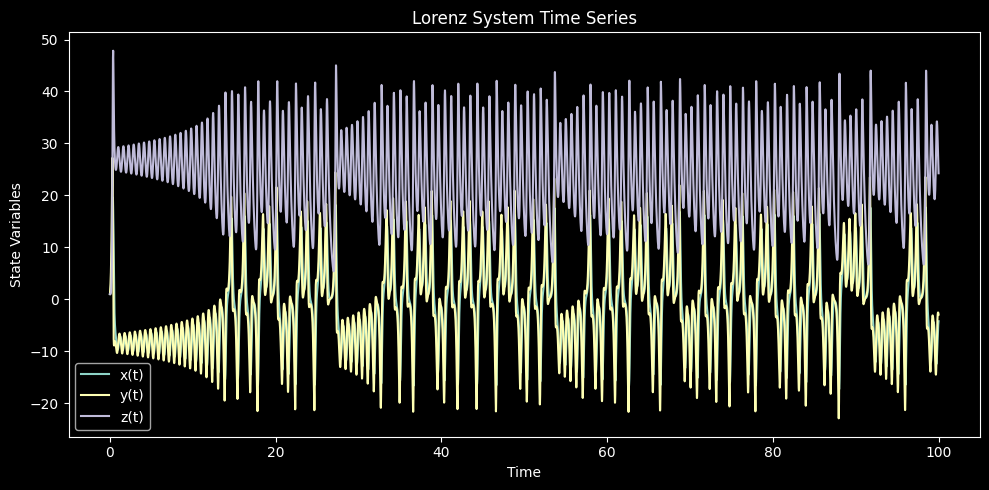

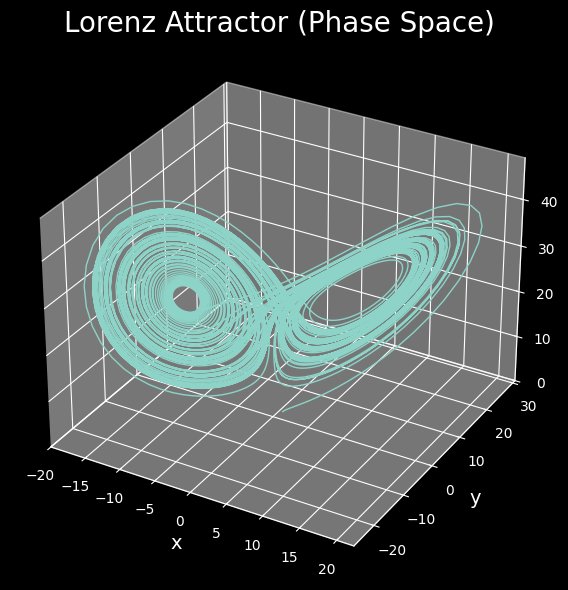

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# Lorenz system
def lorenz(t, X, sigma=10.0, rho=28.0, beta=8/3):
    x, y, z = X
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

# Parameters
sigma, rho, beta = 10.0, 28.0, 8/3
X0 = [1.0, 1.0, 1.0]
t0, tf = 0.0, 100
t = np.linspace(t0, tf, 8000)

# Solve IVP
sol = solve_ivp(
    lorenz,
    (t0, tf),
    X0,
    t_eval=t,
    args=(sigma, rho, beta),
)
from IPython.display import display, Math
print("Lorenz Equations:")

display(Math(r"(x)' = -10 x + 10 y"))
display(Math(r"(y)' = 28 x - y - x z "))
display(Math(r"(z)' = -2.667z + x y"))
x, y, z = sol.y


# Time series (same figure)
plt.figure(figsize=(10, 5))
plt.plot(t, x, label="x(t)")
plt.plot(t, y, label="y(t)")
plt.plot(t, z, label="z(t)")
plt.xlabel("Time")
plt.ylabel("State Variables")
plt.title("Lorenz System Time Series")
plt.legend()
plt.tight_layout()
plt.show()


# 3D Phase Plot

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(x, y, z, linewidth=1.0)

ax.set_xlabel("x", fontsize = 14)
ax.set_ylabel("y", fontsize = 14)
ax.set_zlabel("z", fontsize = 14)
ax.set_title("Lorenz Attractor (Phase Space)", fontsize = 20)
plt.tight_layout()
plt.show()

Discovered equations:
(x)' = -9.970 x +  9.970 y
(y)' =  27.500 x + -0.898 y + -0.985 x z
(z)' = -2.654 z +  0.995 x y


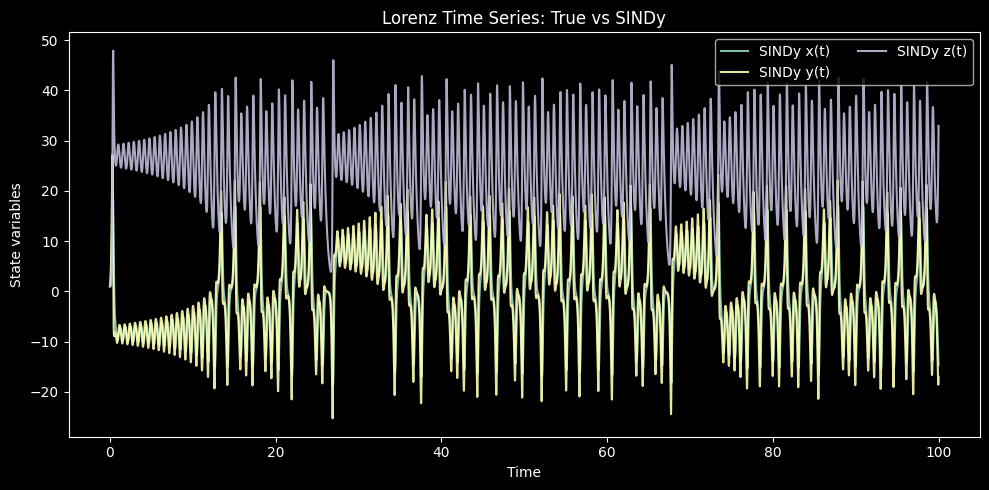

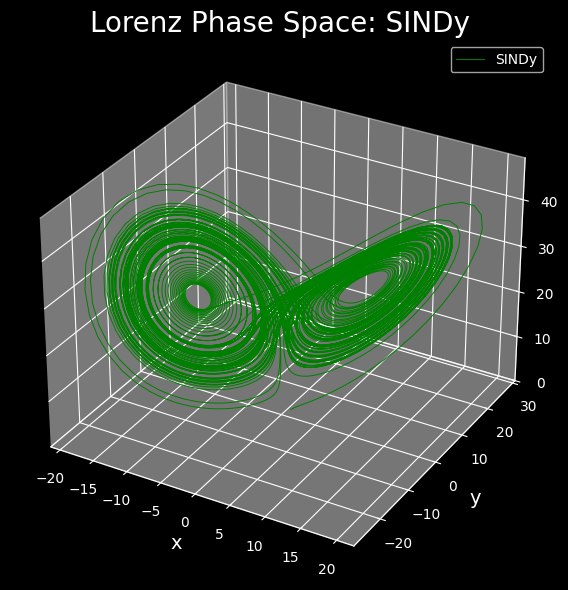

In [2]:

# SINDy: recover Lorenz + plot

import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps


X = np.column_stack([x, y, z])


diff_method = ps.FiniteDifference(order=2)

#  SINDy model
library = ps.PolynomialLibrary(degree=2, include_interaction=True, include_bias=True)
optimizer = ps.STLSQ(threshold=0.05)  # increase threshold for more sparsity

model = ps.SINDy(
    feature_library=library,
    optimizer=optimizer,
    differentiation_method=diff_method,
)

dt = t[1] - t[0]
model.fit(X, t=dt, feature_names=["x", "y", "z"])
print("Discovered equations:")
model.print()

#initial condition
X0_sindy = X[0]
X_sindy = model.simulate(X0_sindy, t)

xs, ys, zs = X_sindy.T


# Time series: SINDy vs True

plt.figure(figsize=(10, 5))

plt.plot(t, xs, label="SINDy x(t)", alpha=0.9)
plt.plot(t, ys, label="SINDy y(t)", alpha=0.9)
plt.plot(t, zs, label="SINDy z(t)", alpha=0.9)

plt.xlabel("Time")
plt.ylabel("State variables")
plt.title("Lorenz Time Series: True vs SINDy")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


# 3D phase plot: SINDy vs True

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(xs, ys, zs, linewidth=0.7, label="SINDy", color="g")

ax.set_xlabel("x",fontsize = 14)
ax.set_ylabel("y",fontsize = 14)
ax.set_zlabel("z",fontsize = 14)
ax.set_title("Lorenz Phase Space: SINDy", fontsize = 20)
ax.legend()
plt.tight_layout()
plt.show()


===== STLSQ discovered equations =====
(x)' = -9.970 x +  9.970 y
(y)' =  27.500 x + -0.898 y + -0.985 x z
(z)' = -2.654 z +  0.995 x y

===== SR3 discovered equations =====
(x)' = -10.116 x +  10.075 y
(y)' =  27.278 x + -0.736 y + -0.978 x z
(z)' = -2.582 z +  0.951 x y


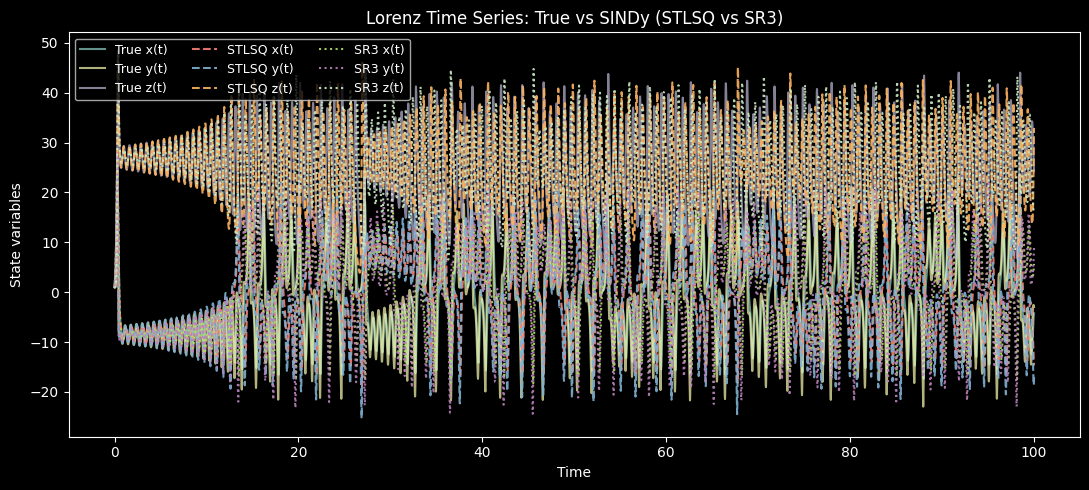

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps

# Data (from Lorenz solve cell)

X = np.column_stack([x, y, z])
dt = t[1] - t[0]
X0 = X[0]


# SINDy setup

library = ps.PolynomialLibrary(degree=2, include_interaction=True, include_bias=False)
diff_method = ps.FiniteDifference(order=2)

def fit_sindy_model(optimizer, name):
    model = ps.SINDy(
        feature_library=library,
        optimizer=optimizer,
        differentiation_method=diff_method,
    )
    model.fit(X, t=dt, feature_names=["x", "y", "z"])
    print(f"\n===== {name} discovered equations =====")
    model.print()
    return model


# 1) STLSQ

stlsq = ps.STLSQ(threshold=0.05)  #  threshold
model_stlsq = fit_sindy_model(stlsq, "STLSQ")

X_stlsq = model_stlsq.simulate(X0, t)
xs1, ys1, zs1 = X_stlsq.T

# 2) SR3

sr3 = ps.SR3(reg_weight_lam=0.1)  # threshold
model_sr3 = fit_sindy_model(sr3, "SR3")

X_sr3 = model_sr3.simulate(X0, t)
xs2, ys2, zs2 = X_sr3.T


# time series - Lorenz vs SINDy (STLSQ vs SR3)

plt.figure(figsize=(11, 5))
plt.plot(t, x, label="True x(t)", alpha=0.7)
plt.plot(t, y, label="True y(t)", alpha=0.7)
plt.plot(t, z, label="True z(t)", alpha=0.7)

plt.plot(t, xs1, "--", label="STLSQ x(t)", alpha=0.9)
plt.plot(t, ys1, "--", label="STLSQ y(t)", alpha=0.9)
plt.plot(t, zs1, "--", label="STLSQ z(t)", alpha=0.9)

plt.plot(t, xs2, ":", label="SR3 x(t)", alpha=0.9)
plt.plot(t, ys2, ":", label="SR3 y(t)", alpha=0.9)
plt.plot(t, zs2, ":", label="SR3 z(t)", alpha=0.9)

plt.xlabel("Time")
plt.ylabel("State variables")
plt.title("Lorenz Time Series: True vs SINDy (STLSQ vs SR3)")
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

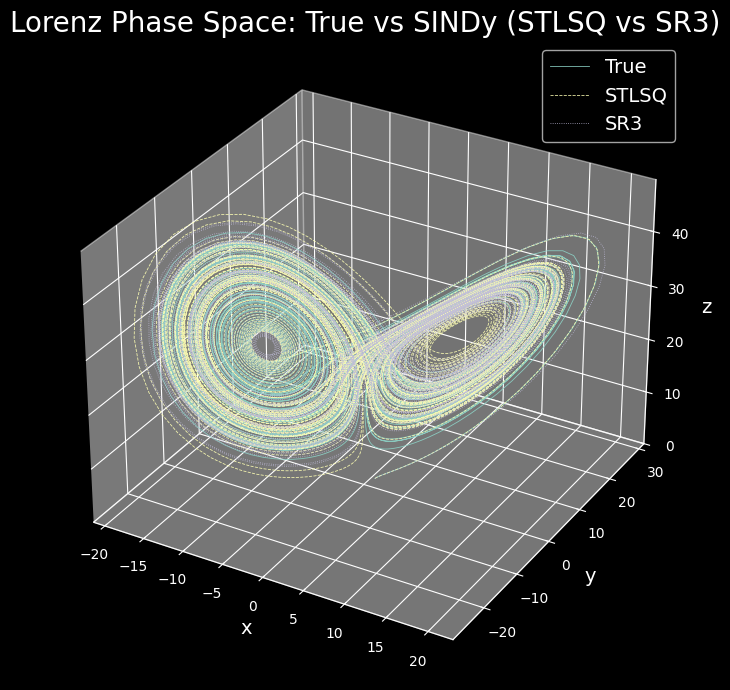

In [14]:
# 3D phase space - Lorenz vs SINDy (STLSQ vs SR3)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(x, y, z, linewidth=0.6, label="True", alpha=0.9)
ax.plot(xs1, ys1, zs1, linewidth=0.6, linestyle="--", label="STLSQ", alpha=0.9)
ax.plot(xs2, ys2, zs2, linewidth=0.6, linestyle=":", label="SR3", alpha=0.9)

ax.set_xlabel("x", fontsize = 14)
ax.set_ylabel("y", fontsize = 14)
ax.set_zlabel("z", fontsize = 14)
ax.set_title("Lorenz Phase Space: True vs SINDy (STLSQ vs SR3)", fontsize = 20)
ax.legend(fontsize = 14)
plt.tight_layout()
plt.show()

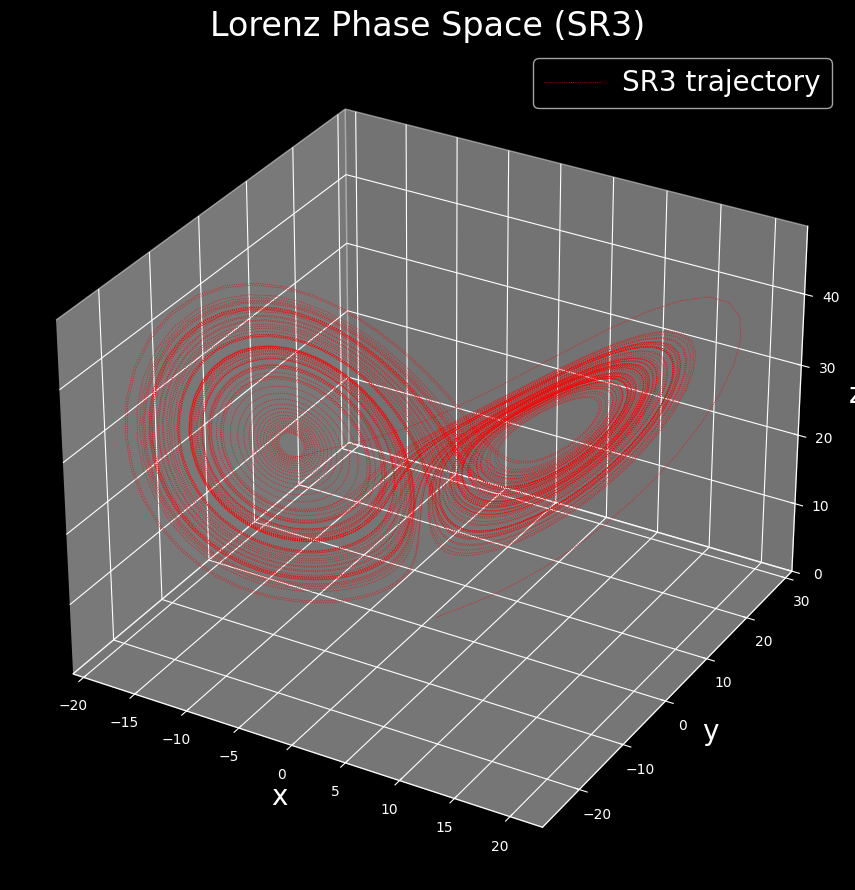

In [5]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")
ax.plot(xs2, ys2, zs2, linewidth=0.6, linestyle=":", label="SR3 trajectory", alpha=0.9, color="red")
ax.set_title("Lorenz Phase Space (SR3)", fontsize = 24 )
ax.set_xlabel("x", fontsize = 20)
ax.set_ylabel("y", fontsize = 20)
ax.set_zlabel("z", fontsize = 20)
plt.legend(fontsize = 20)

plt.tight_layout()
plt.show()

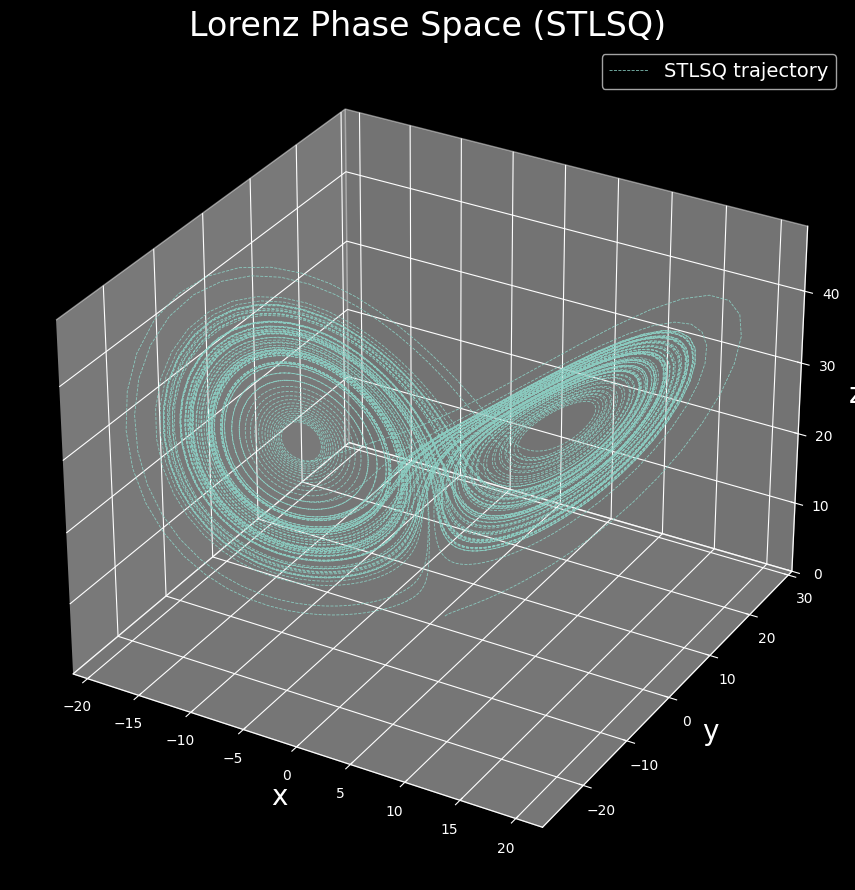

In [6]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")
ax.plot(xs1, ys1, zs1, linewidth=0.6, linestyle="--", label="STLSQ trajectory", alpha=0.9)
ax.set_title("Lorenz Phase Space (STLSQ)", fontsize = 24 )
ax.set_xlabel("x", fontsize = 20)
ax.set_ylabel("y", fontsize = 20)
ax.set_zlabel("z", fontsize = 20)
plt.legend(fontsize = 14)

plt.tight_layout()
plt.show()

In [16]:
# One-step RMSE: STLSQ vs SR3

X_true = np.column_stack([x, y, z])
dt = t[1] - t[0]

def one_step_rmse(model, X, dt):

    Xdot = model.predict(X)
    X_next = X[:-1] + dt * Xdot[:-1]  # first-order Taylor expansion
    err = X_next - X[1:]
    rmse_per_state = np.sqrt(np.mean(err**2, axis=0))
    rmse_overall = np.sqrt(np.mean(err**2))
    return rmse_overall, rmse_per_state

rmse_stlsq, rmse_stlsq_vec = one_step_rmse(model_stlsq, X_true, dt)
rmse_sr3,   rmse_sr3_vec   = one_step_rmse(model_sr3,   X_true, dt)

print("One-step RMSE (overall):")
print(f"  STLSQ: {rmse_stlsq:.6g}")
print(f"  SR3  : {rmse_sr3:.6g}")

print("\nOne-step RMSE (per state) [x, y, z]:")
print(f"  STLSQ: {rmse_stlsq_vec}")
print(f"  SR3  : {rmse_sr3_vec}")

One-step RMSE (overall):
  STLSQ: 0.0769257
  SR3  : 0.323195

One-step RMSE (per state) [x, y, z]:
  STLSQ: [0.05567577 0.08722432 0.08393353]
  SR3  : [0.42474097 0.32309445 0.16902444]


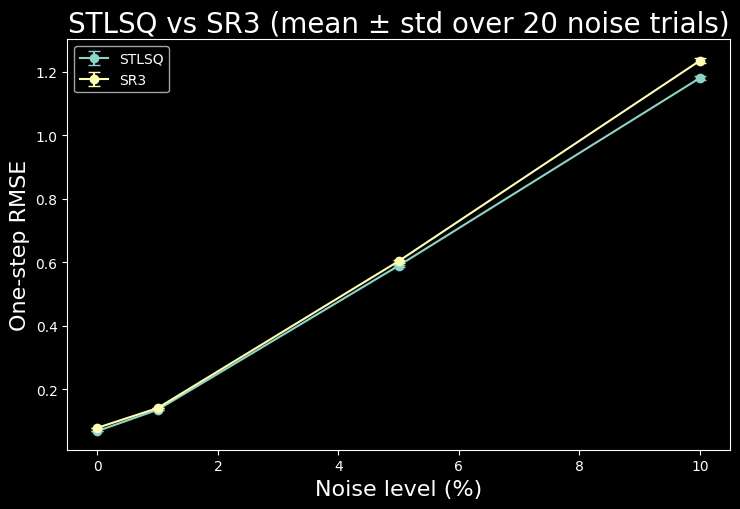

In [17]:
# STSLQ vs SR3 mean plot

X_clean = np.column_stack([x, y, z])
dt = t[1] - t[0]

#
noise_levels = [0.0, 0.01, 0.05, 0.1]
n_seeds = 20
threshold = 0.05

#SINDy setup
library = ps.PolynomialLibrary(degree=2)
diff_method = ps.FiniteDifference(order=2)


def one_step_rmse(model, X, dt):
    Xdot = model.predict(X)
    X_pred_next = X[:-1] + dt * Xdot[:-1]
    err = X_pred_next - X[1:]
    return np.sqrt(np.mean(err**2))

# store results
rmse_stlsq = np.zeros((len(noise_levels), n_seeds))
rmse_sr3   = np.zeros((len(noise_levels), n_seeds))

signal_std = np.std(X_clean, axis=0)

for i, nl in enumerate(noise_levels):
    for s in range(n_seeds):
        rng = np.random.default_rng(s)

        # noisy measurements
        noise = rng.normal(0.0, nl * signal_std, size=X_clean.shape)
        X_noisy = X_clean + noise

        # STLSQ
        model_stlsq = ps.SINDy(
            feature_library=library,
            optimizer=ps.STLSQ(threshold=threshold),
            differentiation_method=diff_method,
        )
        model_stlsq.fit(X_noisy, t=dt, feature_names=["x", "y", "z"])
        rmse_stlsq[i, s] = one_step_rmse(model_stlsq, X_noisy, dt)

        # SR3
        model_sr3 = ps.SINDy(
            feature_library=library,
            optimizer=ps.SR3(reg_weight_lam=0.1),
            differentiation_method=diff_method,
        )
        model_sr3.fit(X_noisy, t=dt, feature_names=["x", "y", "z"])
        rmse_sr3[i, s] = one_step_rmse(model_sr3, X_noisy, dt)

stlsq_mean = rmse_stlsq.mean(axis=1)
stlsq_std  = rmse_stlsq.std(axis=1, ddof=1)

sr3_mean = rmse_sr3.mean(axis=1)
sr3_std  = rmse_sr3.std(axis=1, ddof=1)

# error bars
x_pct = np.array(noise_levels) * 100

plt.figure(figsize=(7.5, 5.2))
plt.errorbar(x_pct, stlsq_mean, yerr=stlsq_std, marker="o", capsize=4, label="STLSQ")
plt.errorbar(x_pct, sr3_mean,   yerr=sr3_std,   marker="o", capsize=4, label="SR3")
plt.xlabel("Noise level (%)", fontsize=16)
plt.ylabel("One-step RMSE", fontsize=16)
plt.title(f"STLSQ vs SR3 (mean ± std over {n_seeds} noise trials)", fontsize=20)
plt.legend()
plt.tight_layout()
plt.show()